In [2]:
!pip install pandas transformers torch tqdm

In [3]:
import pandas as pd

import torch

import random

from tqdm import tqdm

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv("/content/drive/MyDrive/amazon_review_bi.csv")

In [6]:
df.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,text,label,verified
0,US,12439300,RDQSBL4NPZJ0P,B004LUJRIQ,568018301,Undercover Mama Nursing Tank Top - Perfect Bre...,Apparel,4,0,0,0,1,So handy!,"It fits a little small, but the concept is SO ...",2014-10-25,"It fits a little small, but the concept is SO ...",2,1
1,US,1664388,R86P8GNY6BTCY,B00DNSP2WM,415098073,U.S. Polo Assn. Junior's Fleece Jacket with Fo...,Apparel,5,0,0,0,0,Five Stars,Beautiful jacket. Exactly as described. A sure...,2015-02-01,Beautiful jacket. Exactly as described. A sure...,2,0
2,US,1456177,R3V5ZKSR4KFFQL,B00CYN6QYU,356900417,Jinhuanshow Women's Jumpsuits Slim Leisure Clo...,Apparel,4,0,0,0,1,Four Stars,Love it. It is exactly what it says in descrip...,2014-08-09,Love it. It is exactly what it says in descrip...,2,1
3,US,32484266,R1RMQQYJ4GIU15,B0045D7VZ0,939464179,Secret Wishes Wonder Woman Costume,Apparel,4,0,0,0,1,Rock it baby!,"I'm usually a 12-14 and this fit perfect, the ...",2013-10-25,"I'm usually a 12-14 and this fit perfect, the ...",2,1
4,US,14783477,R3F149DELOVOHA,B00BCWHX6O,704836019,Lee Women's Petite Natural Fit Pull On Barely ...,Apparel,4,0,0,0,1,Great jeans!,After trying to order an additional pair in an...,2014-10-16,After trying to order an additional pair in an...,2,1


In [7]:
df = df.dropna(subset=["review_body", "product_title", "review_date"])

df["year"] = pd.to_datetime(df["review_date"]).dt.year

In [8]:
top_products = df["product_title"].value_counts().head(10).index

df = df[df["product_title"].isin(top_products)]

In [9]:
from huggingface_hub import notebook_login

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("t5-small")

model = AutoModelForSeq2SeqLM.from_pretrained("t5-small").to(device)

model.eval()

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=512, bias=False)
              (k): Linear(in_features=512, out_features=512, bias=False)
              (v): Linear(in_features=512, out_features=512, bias=False)
              (o): Linear(in_features=512, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 8)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=512, out_features=2048, bias=False)
              (wo): Linear(in_features=2048, out_features=512, bias=False)
              (dropout): Drop

In [30]:
import random

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def summarize_reviews(reviews, max_reviews=20):

    reviews = random.sample(reviews, min(len(reviews), max_reviews))

    text = " ".join(reviews)

    text = text[:512]

    input_text = "summarize: " + text

    inputs = tokenizer(

        input_text,

        return_tensors="pt",

        truncation=True

    )


    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():

        outputs = model.generate(

            inputs["input_ids"],

            max_length=60,

            min_length=15,

            num_beams=4,

            early_stopping=True

        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [31]:
results = []

grouped = df.groupby(["product_title", "year"])

for (product, year), group in tqdm(grouped):

    reviews = group["review_body"].astype(str).tolist()

    summary = summarize_reviews(reviews)

    avg_sentiment = group["label"].mean()

    results.append({

        "product": product,

        "year": year,

        "num_reviews": len(reviews),

        "avg_sentiment": avg_sentiment,

        "summary": summary

    })

df_summary = pd.DataFrame(results)

100%|██████████| 66/66 [00:09<00:00,  7.23it/s]


In [24]:
df_summary.head()

,product,year,num_reviews,avg_sentiment,summary
0,Ann Chery Women's Faja Clasica Waist Cincher,2013,40,1.650000,the first time it took me 20mins to put it on ...
1,Ann Chery Women's Faja Clasica Waist Cincher,2014,1340,1.505970,I'm a small/med in my upper half and large to ...
2,Ann Chery Women's Faja Clasica Waist Cincher,2015,1999,1.480740,i got a 36 because my bra size is C36. it was ...
3,Ann Chery Women's Faja Deportiva Workout Waist...,2013,12,1.666667,"I had to return the size I purchased, but i wi..."
4,Ann Chery Women's Faja Deportiva Workout Waist...,2014,1103,1.503173,the small is like super super mega small and I...


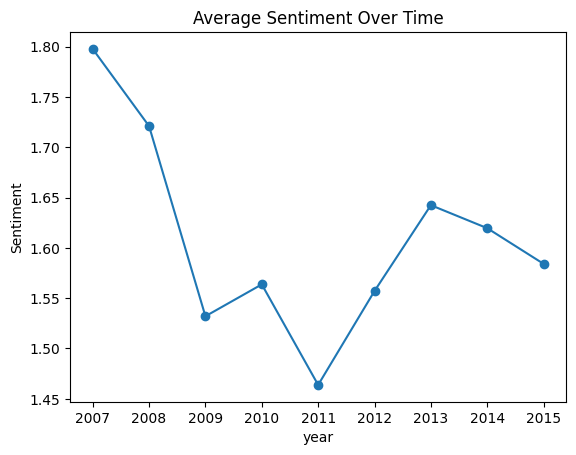

In [32]:
import matplotlib.pyplot as plt

df_summary.groupby("year")["avg_sentiment"].mean().plot(marker="o")

plt.title("Average Sentiment Over Time")

plt.ylabel("Sentiment")

plt.show()

In [33]:
df_summary.groupby("product")["avg_sentiment"].mean().sort_values(ascending=False)

,avg_sentiment
product,
Columbia Women's Benton Springs Full-Zip Fleece Jacket,1.757983
Playtex Women's 18 Hour Original Comfort Strap Bra #4693,1.728359
Levi's Men's 511 Slim Fit Jean,1.724385
SHARKK® Aluminum Wallet Credit Card Holder With RFID Protection Made By SHARKK Brands,1.581364
Squeem 'Perfect Waist' Contouring Cincher,1.580849
Glamorise Women's No-Bounce Full-Support Sport Bra,1.572720
Ann Chery Women's Faja Deportiva Workout Waist Cincher,1.566003
Ann Chery Women's Faja Clasica Waist Cincher,1.545570
Levi's Men's 501 Original-Fit Jean,1.486875


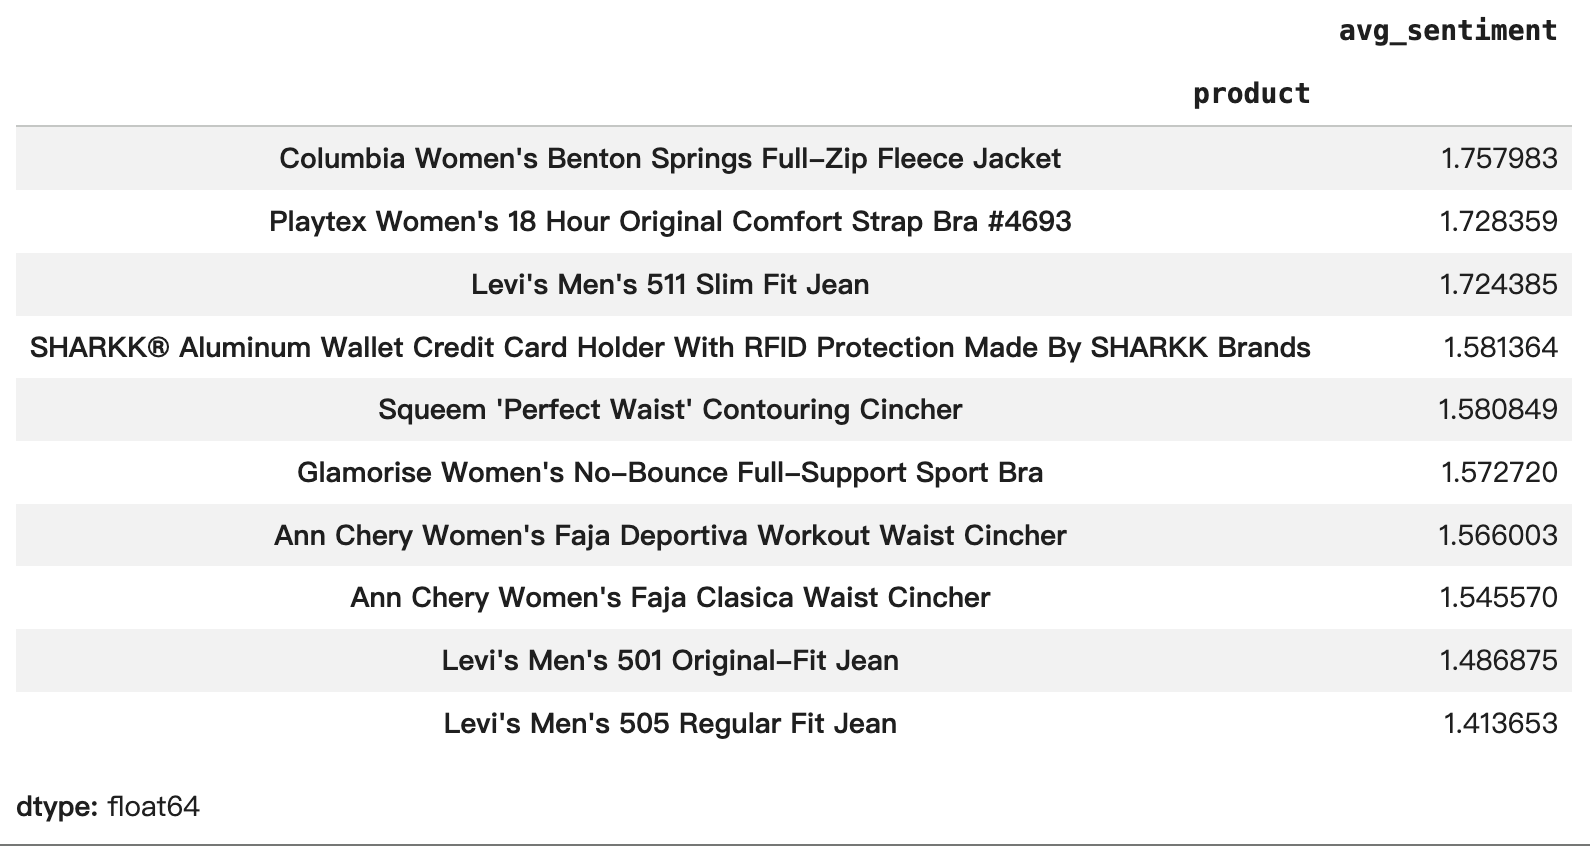

In [34]:
for y in sorted(df_summary["year"].unique()):

    print("\nYEAR:", y)

    print(

        df_summary[df_summary["year"] == y]

        .groupby("product")["avg_sentiment"]

        .mean()

        .sort_values(ascending=False)

    )


YEAR: 2007
product
Levi's Men's 511 Slim Fit Jean                              2.000000
Playtex Women's 18 Hour Original Comfort Strap Bra #4693    2.000000
Squeem 'Perfect Waist' Contouring Cincher                   1.857143
Levi's Men's 505 Regular Fit Jean                           1.333333
Name: avg_sentiment, dtype: float64

YEAR: 2008
product
Levi's Men's 511 Slim Fit Jean                              2.000000
Playtex Women's 18 Hour Original Comfort Strap Bra #4693    1.846154
Squeem 'Perfect Waist' Contouring Cincher                   1.658537
Levi's Men's 501 Original-Fit Jean                          1.600000
Levi's Men's 505 Regular Fit Jean                           1.500000
Name: avg_sentiment, dtype: float64

YEAR: 2009
product
Levi's Men's 511 Slim Fit Jean                              1.777778
Playtex Women's 18 Hour Original Comfort Strap Bra #4693    1.680000
Levi's Men's 505 Regular Fit Jean                           1.632653
Squeem 'Perfect Waist' Contouring Cinche

YEAR: 2007
product
Levi's Men's 511 Slim Fit Jean                              2.000000
Playtex Women's 18 Hour Original Comfort Strap Bra #4693    2.000000
Squeem 'Perfect Waist' Contouring Cincher                   1.857143
Levi's Men's 505 Regular Fit Jean                           1.333333
Name: avg_sentiment, dtype: float64

YEAR: 2008
product
Levi's Men's 511 Slim Fit Jean                              2.000000
Playtex Women's 18 Hour Original Comfort Strap Bra #4693    1.846154
Squeem 'Perfect Waist' Contouring Cincher                   1.658537
Levi's Men's 501 Original-Fit Jean                          1.600000
Levi's Men's 505 Regular Fit Jean                           1.500000
Name: avg_sentiment, dtype: float64

YEAR: 2009
product
Levi's Men's 511 Slim Fit Jean                              1.777778
Playtex Women's 18 Hour Original Comfort Strap Bra #4693    1.680000
Levi's Men's 505 Regular Fit Jean                           1.632653
Squeem 'Perfect Waist' Contouring Cincher                   1.518519
Levi's Men's 501 Original-Fit Jean                          1.051282
Name: avg_sentiment, dtype: float64

YEAR: 2010
product
Playtex Women's 18 Hour Original Comfort Strap Bra #4693    1.840000
Glamorise Women's No-Bounce Full-Support Sport Bra          1.777778
Levi's Men's 511 Slim Fit Jean                              1.607143
Columbia Women's Benton Springs Full-Zip Fleece Jacket      1.500000
Squeem 'Perfect Waist' Contouring Cincher                   1.486486
Levi's Men's 505 Regular Fit Jean                           1.432099
Levi's Men's 501 Original-Fit Jean                          1.302326
Name: avg_sentiment, dtype: float64

YEAR: 2011
product
Columbia Women's Benton Springs Full-Zip Fleece Jacket      1.838710
Playtex Women's 18 Hour Original Comfort Strap Bra #4693    1.640000
Squeem 'Perfect Waist' Contouring Cincher                   1.590909
Levi's Men's 501 Original-Fit Jean                          1.465517
Levi's Men's 511 Slim Fit Jean                              1.420000
Glamorise Women's No-Bounce Full-Support Sport Bra          1.325581
Levi's Men's 505 Regular Fit Jean                           0.965986
Name: avg_sentiment, dtype: float64

YEAR: 2012
product
Columbia Women's Benton Springs Full-Zip Fleece Jacket                                   1.768817
SHARKK® Aluminum Wallet Credit Card Holder With RFID Protection Made By SHARKK Brands    1.751163
Playtex Women's 18 Hour Original Comfort Strap Bra #4693                                 1.700855
Levi's Men's 511 Slim Fit Jean                                                           1.619835
Squeem 'Perfect Waist' Contouring Cincher                                                1.506494
Glamorise Women's No-Bounce Full-Support Sport Bra                                       1.485207
Levi's Men's 501 Original-Fit Jean                                                       1.475524
Levi's Men's 505 Regular Fit Jean                                                        1.148936
Name: avg_sentiment, dtype: float64

YEAR: 2013
product
Columbia Women's Benton Springs Full-Zip Fleece Jacket                                   1.802147
Levi's Men's 511 Slim Fit Jean                                                           1.698381
Playtex Women's 18 Hour Original Comfort Strap Bra #4693                                 1.667678
Ann Chery Women's Faja Deportiva Workout Waist Cincher                                   1.666667
Ann Chery Women's Faja Clasica Waist Cincher                                             1.650000
SHARKK® Aluminum Wallet Credit Card Holder With RFID Protection Made By SHARKK Brands    1.642483
Levi's Men's 501 Original-Fit Jean                                                       1.633621
Glamorise Women's No-Bounce Full-Support Sport Bra                                       1.615267
Squeem 'Perfect Waist' Contouring Cincher                                                1.599271
Levi's Men's 505 Regular Fit Jean                                                        1.448276
Name: avg_sentiment, dtype: float64

YEAR: 2014
product
Columbia Women's Benton Springs Full-Zip Fleece Jacket                                   1.790144
Levi's Men's 511 Slim Fit Jean                                                           1.736131
Levi's Men's 501 Original-Fit Jean                                                       1.668303
SHARKK® Aluminum Wallet Credit Card Holder With RFID Protection Made By SHARKK Brands    1.637819
Levi's Men's 505 Regular Fit Jean                                                        1.625967
Glamorise Women's No-Bounce Full-Support Sport Bra                                       1.608815
Playtex Women's 18 Hour Original Comfort Strap Bra #4693                                 1.571674
Squeem 'Perfect Waist' Contouring Cincher                                                1.547182
Ann Chery Women's Faja Clasica Waist Cincher                                             1.505970
Ann Chery Women's Faja Deportiva Workout Waist Cincher                                   1.503173
Name: avg_sentiment, dtype: float64

YEAR: 2015
product
Columbia Women's Benton Springs Full-Zip Fleece Jacket                                   1.848077
Levi's Men's 501 Original-Fit Jean                                                       1.698425
Levi's Men's 511 Slim Fit Jean                                                           1.660194
Levi's Men's 505 Regular Fit Jean                                                        1.635630
Glamorise Women's No-Bounce Full-Support Sport Bra                                       1.623670
Playtex Women's 18 Hour Original Comfort Strap Bra #4693                                 1.608874
Ann Chery Women's Faja Deportiva Workout Waist Cincher                                   1.528169
Ann Chery Women's Faja Clasica Waist Cincher                                             1.480740
Squeem 'Perfect Waist' Contouring Cincher                                                1.463102
SHARKK® Aluminum Wallet Credit Card Holder With RFID Protection Made By SHARKK Brands    1.293991
Name: avg_sentiment, dtype: float64


In [35]:
df_summary.to_csv("/content/drive/MyDrive/t5_business_insight.csv", index=False)